# Multi-Class Classification with PyTorch

Building a neural net from scratch to classify synthetic data into 4 
classes using `make_blobs`. Covers the full PyTorch classification 
workflow — raw logits, softmax, argmax — plus a manual training loop 
and visualizing how well the model separates the classes.


## Creating the Dataset

Using `make_blobs` to generate 4 well-separated clusters of points, 
keeping it to 2 features so the decision boundary can actually be 
plotted later.

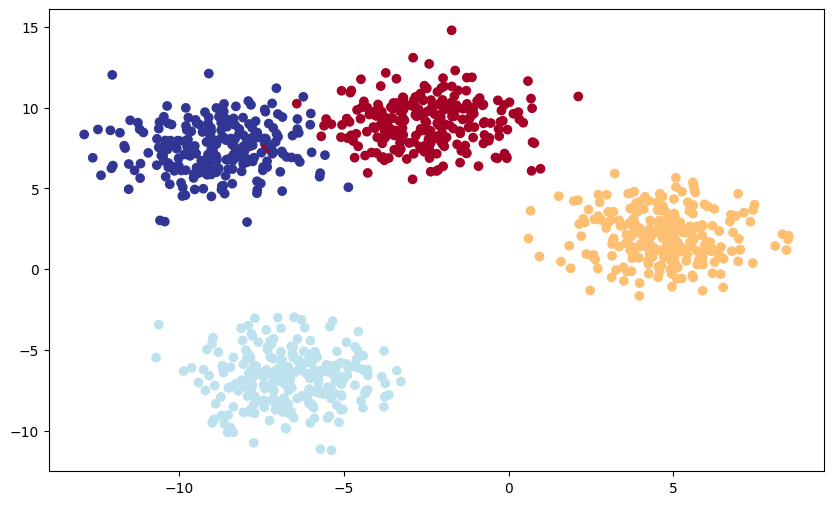

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_STATE = 42

X_blob , y_blob = make_blobs(n_samples=1000,
                             n_features = NUM_FEATURES,
                             random_state = RANDOM_STATE,
                             centers = NUM_CLASSES,
                             cluster_std = 1.5,
                             )

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

X_blob_train , X_blob_test , y_blob_train , y_blob_test = train_test_split(X_blob,
                                                                           y_blob,
                                                                           test_size=0.2,
                                                                           random_state = RANDOM_STATE)

plt.figure(figsize=(10,6))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"the device is {device}")

the device is cpu


## Building the Model

A simple feedforward network — two hidden layers with ReLU in between, 
output layer has 4 units (one per class). The blobs are fairly 
separable, so this doesn't need to be deep or complex.

In [ ]:
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8) :

    super().__init__()

    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)

    )

  def forward(self,x):

    return self.linear_layer_stack(x)

model_0 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8)
model_0

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
X_blob_train.shape , y_blob_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 2., 2., 0.]))

In [ ]:
torch.unique(y_blob)

tensor([0., 1., 2., 3.])

## Loss Function and Optimizer

Using `CrossEntropyLoss` since this is multi-class — it takes raw 
logits directly, no need to apply softmax manually before computing 
loss. SGD with a learning rate of 0.1.

In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.1)


## Sanity Check: Untrained Predictions

Checking what the model outputs before any training. Raw output is 
just logits, so it needs softmax to become class probabilities, then 
argmax to pick the predicted class.

In [ ]:
model_0.eval()
with torch.inference_mode() :

  y_preds = model_0(X_blob_test)

y_preds[:10]

tensor([[ 0.6774,  0.1197, -0.2756, -0.1360],
        [ 1.4097,  1.7665,  0.4286, -0.7826],
        [ 1.0062,  0.1276, -0.6632, -0.1857],
        [ 0.5024,  0.1893, -0.1559, -0.2205],
        [ 1.3432,  0.5243,  0.0022, -0.1451],
        [ 1.5994,  2.0387,  0.5069, -0.8903],
        [ 0.9458,  0.2142, -0.6054, -0.1329],
        [ 1.3892,  0.8839,  0.2012, -0.3234],
        [ 1.1437,  0.0406, -0.7515, -0.2342],
        [ 1.3535,  0.7426,  0.1245, -0.2594]])

In [ ]:
y_pred_probs = torch.softmax(y_preds,dim=1)
print(y_pred_probs[:10])

tensor([[0.4164, 0.2384, 0.1606, 0.1846],
        [0.3430, 0.4901, 0.1286, 0.0383],
        [0.5243, 0.2178, 0.0988, 0.1592],
        [0.3657, 0.2674, 0.1893, 0.1775],
        [0.5186, 0.2287, 0.1357, 0.1171],
        [0.3367, 0.5224, 0.1129, 0.0279],
        [0.4919, 0.2366, 0.1043, 0.1672],
        [0.4788, 0.2889, 0.1460, 0.0864],
        [0.5766, 0.1913, 0.0867, 0.1454],
        [0.4915, 0.2668, 0.1438, 0.0980]])


In [ ]:
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds

tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
        1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 0, 0])

In [ ]:
def accuracy_fn(y_true, y_pred):

  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

## Training the Model

Training for 500 epochs — standard loop: forward pass, compute loss, 
zero gradients, backward pass, optimizer step. Tracking accuracy on 
both train and test sets, printed every 10 epochs.

In [ ]:
torch.manual_seed(42)

epochs = 500

for epoch in range(epochs):

  model_0.train()

  y_logits = model_0(X_blob_train).squeeze()
  y_preds = torch.argmax(torch.softmax(y_logits,dim=1),dim=1)

  loss = loss_fn(y_logits,y_blob_train.type(torch.LongTensor))
  acc = accuracy_fn(y_true=y_blob_train,
                    y_pred = y_preds)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():

    test_logits = model_0(X_blob_test)
    test_preds = torch.argmax(torch.softmax(test_logits,dim=1),dim=1)

    test_loss = loss_fn(test_logits,y_blob_test.type(torch.LongTensor))

    test_acc = accuracy_fn(y_true = y_blob_test,
                           y_pred = test_preds)

  if epoch%10==0:

    print(f"Epoch : {epoch} | Loss : {loss:.5f} | Accuracy : {acc:.2f}% | Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}%")


Epoch : 0 | Loss : 1.92451 | Accuracy : 25.00% | Test Loss : 1.52602 | Test Accuracy : 24.50%
Epoch : 10 | Loss : 0.49775 | Accuracy : 75.88% | Test Loss : 0.41092 | Test Accuracy : 90.00%
Epoch : 20 | Loss : 0.27277 | Accuracy : 99.00% | Test Loss : 0.21788 | Test Accuracy : 99.00%
Epoch : 30 | Loss : 0.13935 | Accuracy : 99.12% | Test Loss : 0.11075 | Test Accuracy : 99.50%
Epoch : 40 | Loss : 0.08489 | Accuracy : 99.12% | Test Loss : 0.06738 | Test Accuracy : 99.50%
Epoch : 50 | Loss : 0.06273 | Accuracy : 99.12% | Test Loss : 0.04900 | Test Accuracy : 99.50%
Epoch : 60 | Loss : 0.05155 | Accuracy : 99.12% | Test Loss : 0.03954 | Test Accuracy : 99.50%
Epoch : 70 | Loss : 0.04510 | Accuracy : 99.12% | Test Loss : 0.03398 | Test Accuracy : 99.50%
Epoch : 80 | Loss : 0.04096 | Accuracy : 99.12% | Test Loss : 0.03033 | Test Accuracy : 99.50%
Epoch : 90 | Loss : 0.03809 | Accuracy : 99.12% | Test Loss : 0.02779 | Test Accuracy : 99.50%
Epoch : 100 | Loss : 0.03599 | Accuracy : 99.12% | 

**Observation:** loss drops fast in the first ~20 epochs and accuracy 
on both train and test jumps above 90% almost immediately. Makes sense 
— the blobs don't overlap much, so this isn't a hard problem once the 
model starts learning.

In [ ]:
y_logits

tensor([[-1.2556,  9.8629, -2.6992, -6.1444],
        [10.0898, -1.3455, -5.8315, -0.2631],
        [-6.7727, -2.2762, 10.8099, -2.1083],
        ...,
        [10.5749, -0.3446, -6.4534, -1.2324],
        [-5.3817, -1.6718,  8.6068, -1.7919],
        [ 1.6086, -6.4034,  0.6216, 10.3228]], grad_fn=<SqueezeBackward0>)

## Evaluating on the Test Set

Switching to eval mode and running the trained model on the test set, 
then comparing predictions against actual labels.

In [ ]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_blob_test)

y_logits[:10]

tensor([[ 0.0478,  9.6563, -3.5721, -6.2549],
        [ 3.4386, -5.5317, -1.3932,  9.6748],
        [-5.4516, -1.3602,  8.5209, -1.8891],
        [-0.8720,  6.3924, -1.6088, -3.9195],
        [10.3667,  2.2526, -7.3657, -2.5680],
        [ 3.7794, -6.8637, -1.3874, 11.9049],
        [-4.9957, -0.4485,  7.3878, -1.9539],
        [ 9.7459, -0.9345, -5.7109, -0.7055],
        [-6.5877, -2.6663, 10.6529, -1.6805],
        [ 9.9510,  0.1054, -6.2398, -1.3901]])

In [ ]:
y_pred_probs = torch.softmax(y_logits,dim=1)
y_pred_probs[:10]

tensor([[6.7151e-05, 9.9993e-01, 1.7986e-06, 1.2298e-07],
        [1.9535e-03, 2.4834e-07, 1.5574e-05, 9.9803e-01],
        [8.5469e-07, 5.1129e-05, 9.9992e-01, 3.0128e-05],
        [6.9925e-04, 9.9893e-01, 3.3471e-04, 3.3200e-05],
        [9.9970e-01, 2.9920e-04, 1.9896e-08, 2.4120e-06],
        [2.9583e-04, 7.0596e-09, 1.6870e-06, 9.9970e-01],
        [4.1851e-06, 3.9494e-04, 9.9951e-01, 8.7648e-05],
        [9.9995e-01, 2.2992e-05, 1.9372e-07, 2.8907e-05],
        [3.2544e-08, 1.6425e-06, 9.9999e-01, 4.4023e-06],
        [9.9994e-01, 5.2973e-05, 9.2976e-08, 1.1874e-05]])

In [ ]:
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [ ]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

## Visualizing the Decision Boundary

Using `plot_decision_boundary` from 
[mrdbourke/pytorch-deep-learning](https://github.com/mrdbourke/pytorch-deep-learning) 
to see how the model separates the 4 classes on train vs. test data.

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print ("helper_functions. py already exists, skipping download")
else:
  print ("Download helper_functions-py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py" , "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions , plot_decision_boundary

Download helper_functions-py


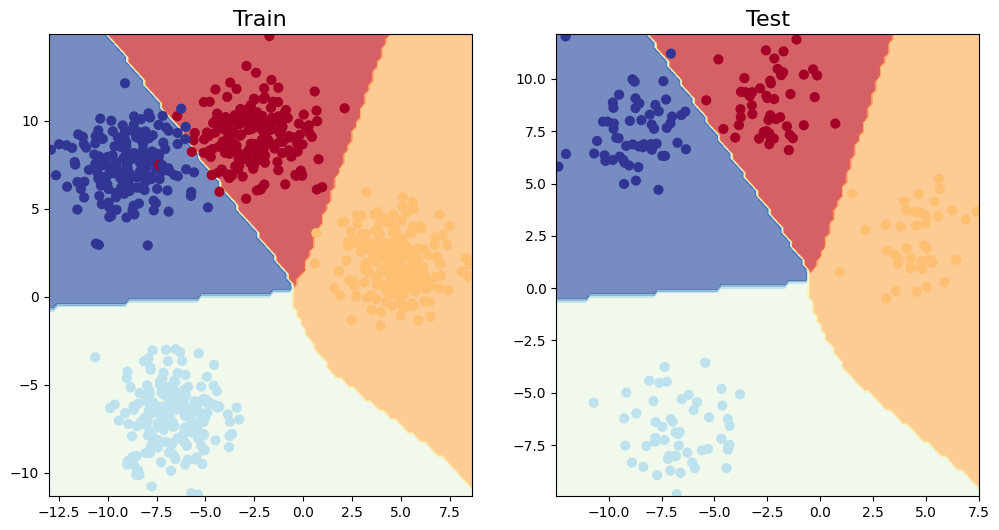

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train",fontsize=16)
plot_decision_boundary(model_0,X_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("Test",fontsize=16)
plot_decision_boundary(model_0,X_blob_test,y_blob_test)

**Observation:** clean boundaries between all 4 blobs on both train and 
test, no visible misclassifications. Given how separated the clusters 
were to start with, this is close to the best result possible here.

## Key Takeaway

For well-separated data, even a small network converges fast and hits 
high accuracy. The real test of this architecture (linear layers + 
ReLU) comes in the next notebook, where the data isn't linearly 
separable at all.